INFO:__main__:Calculating TDA Features for KS...


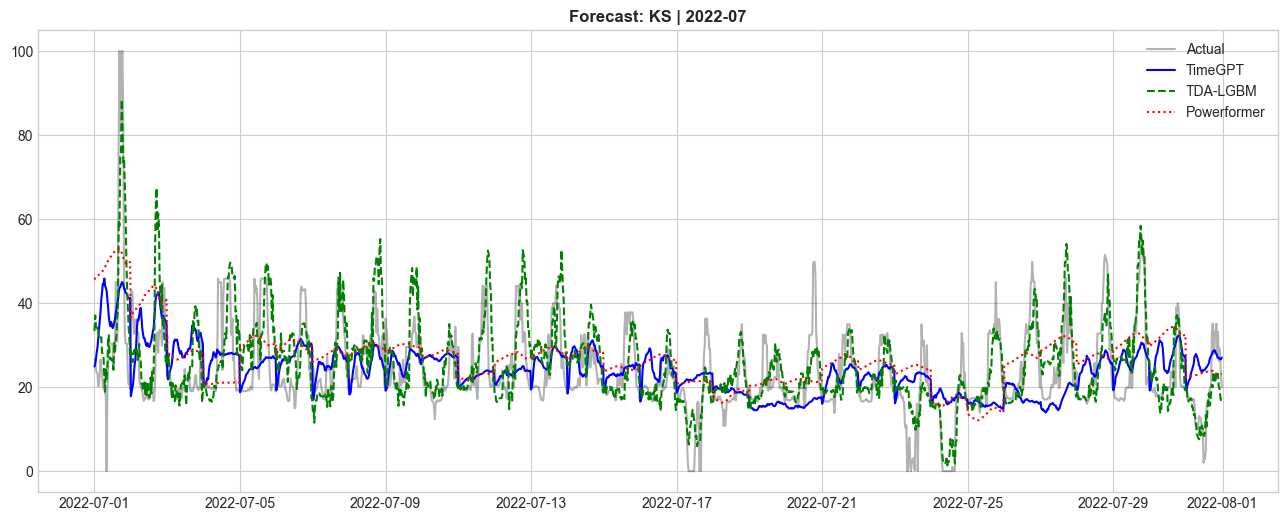

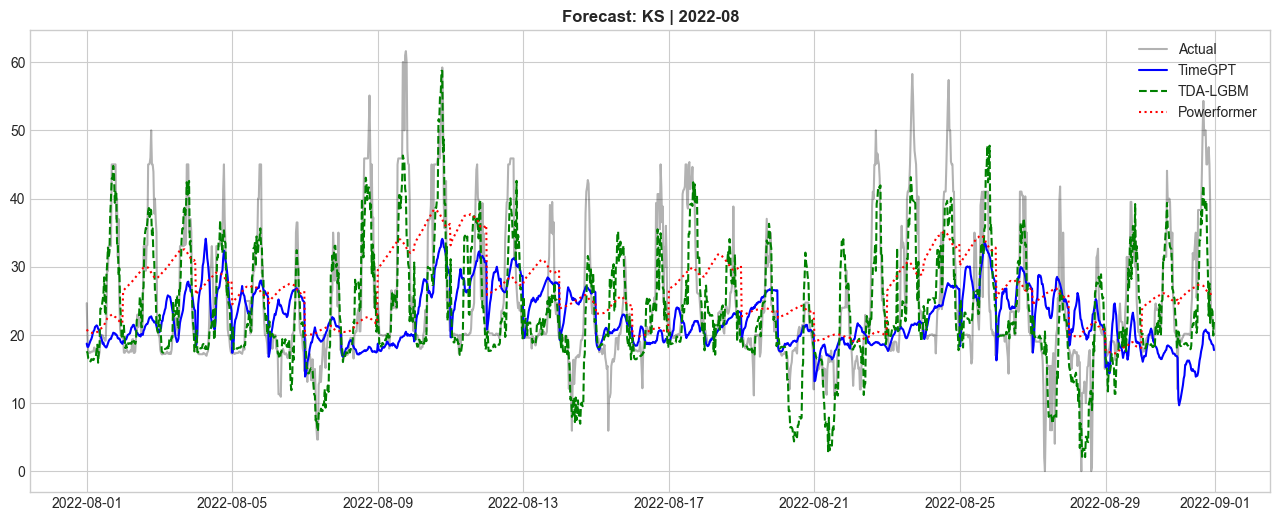

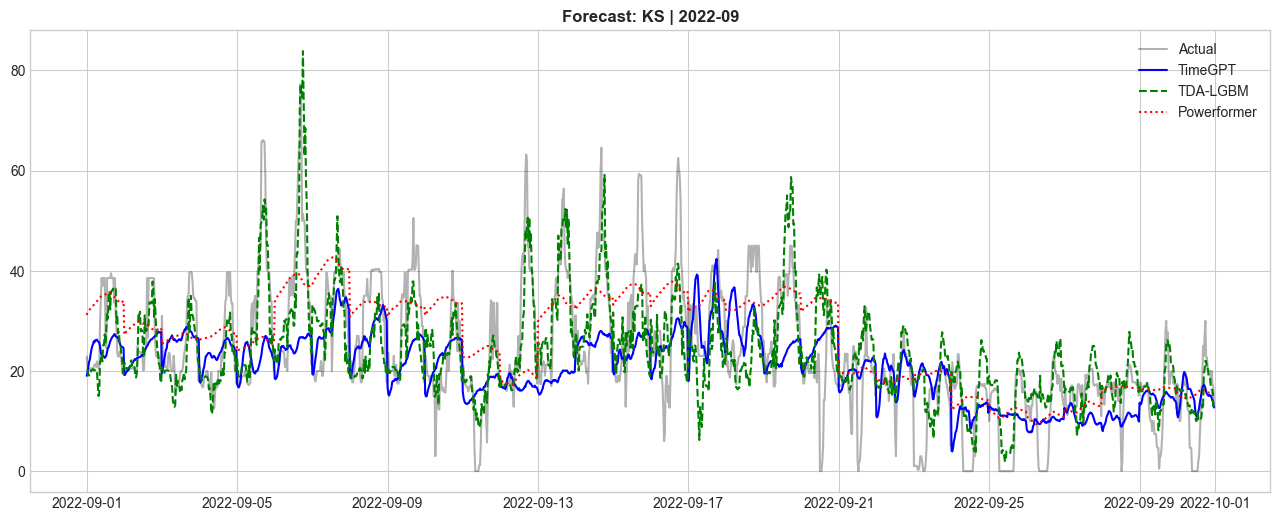

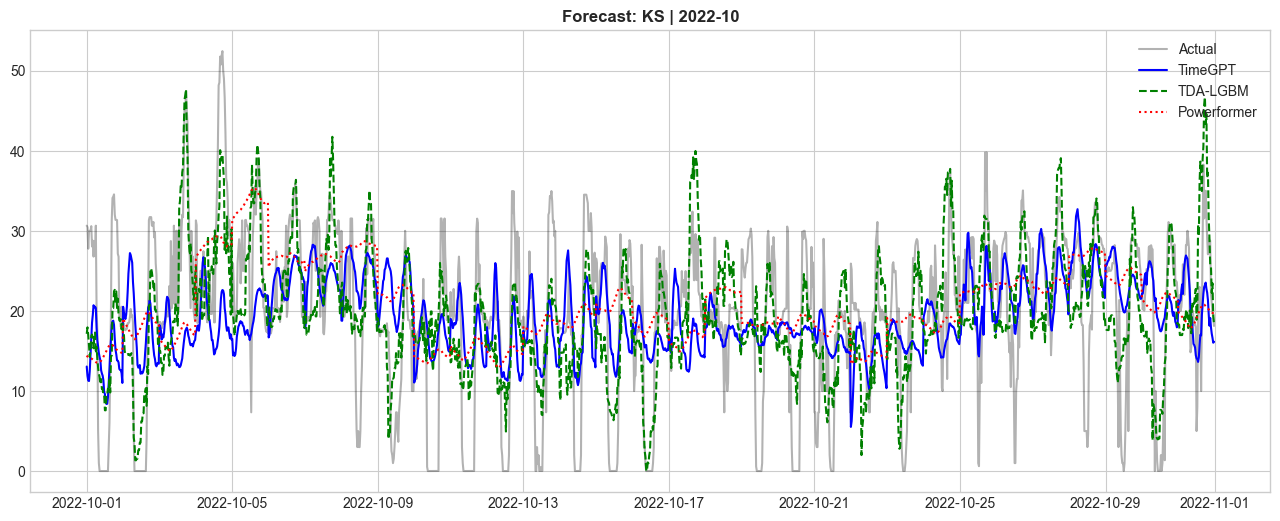

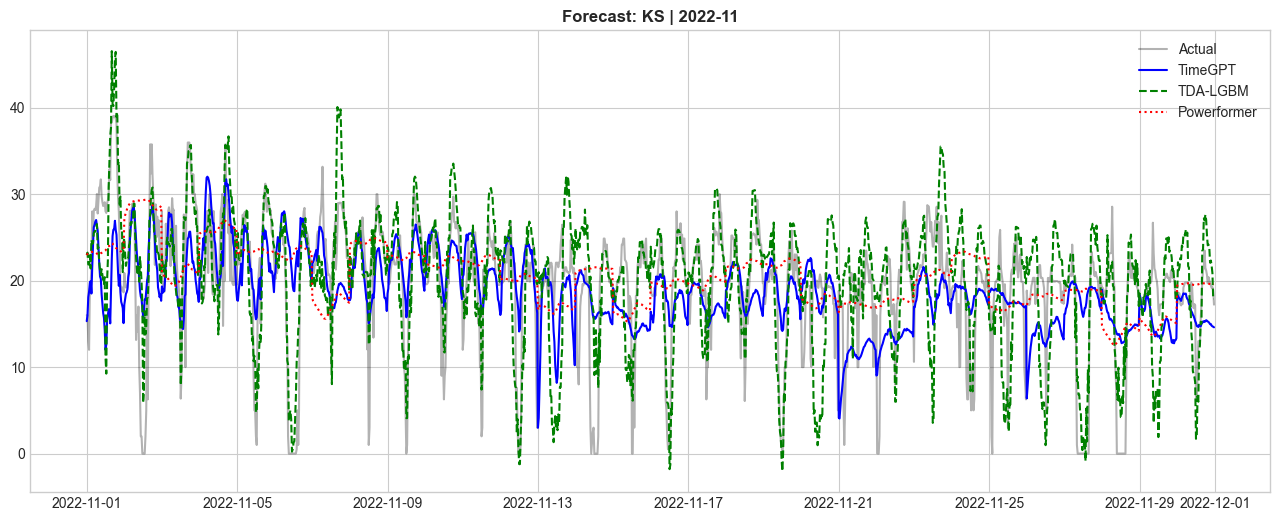

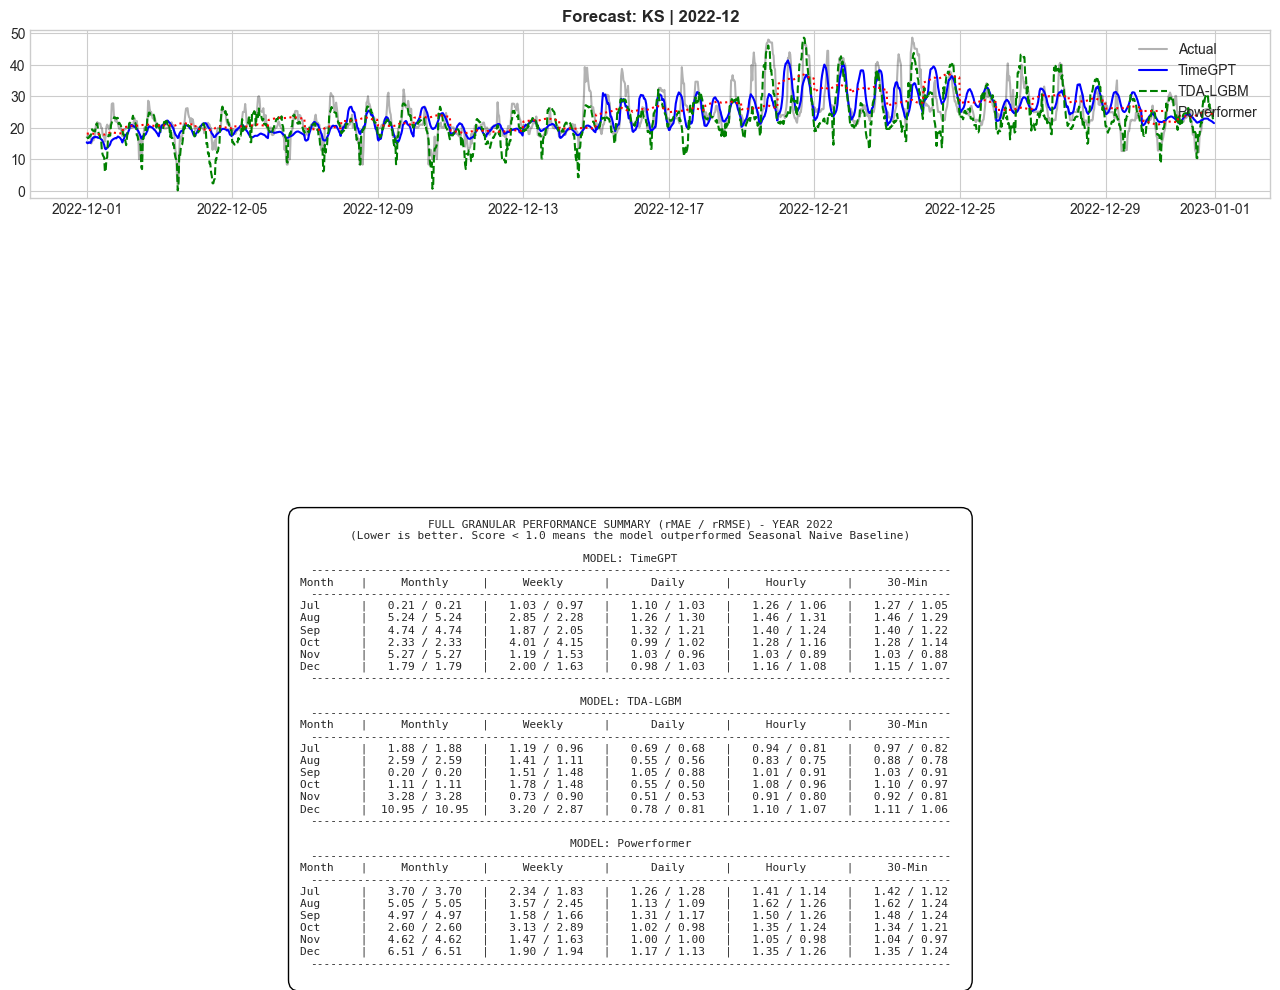

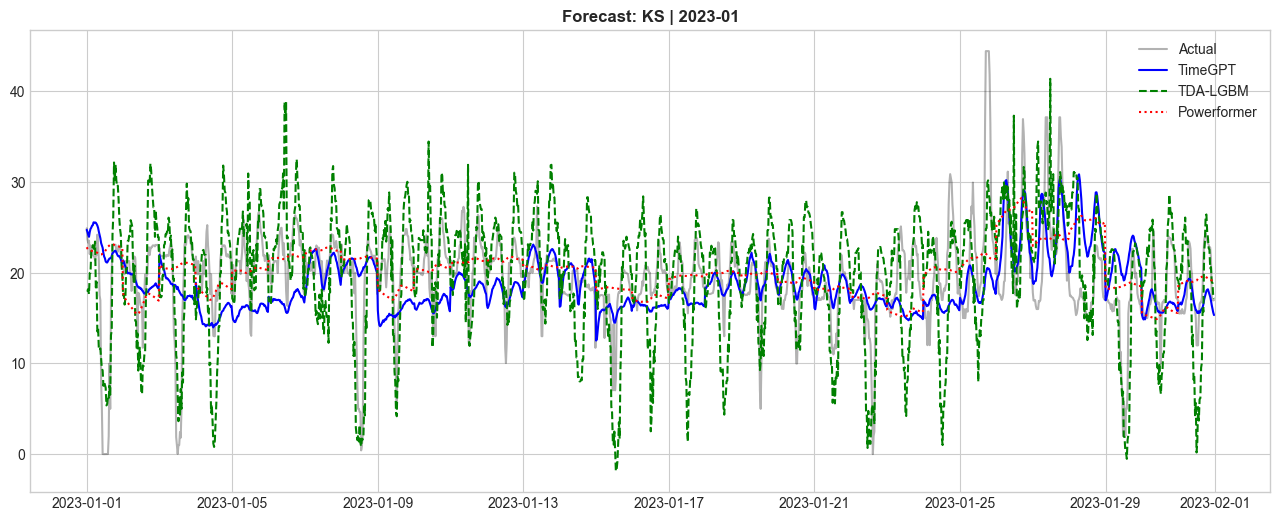

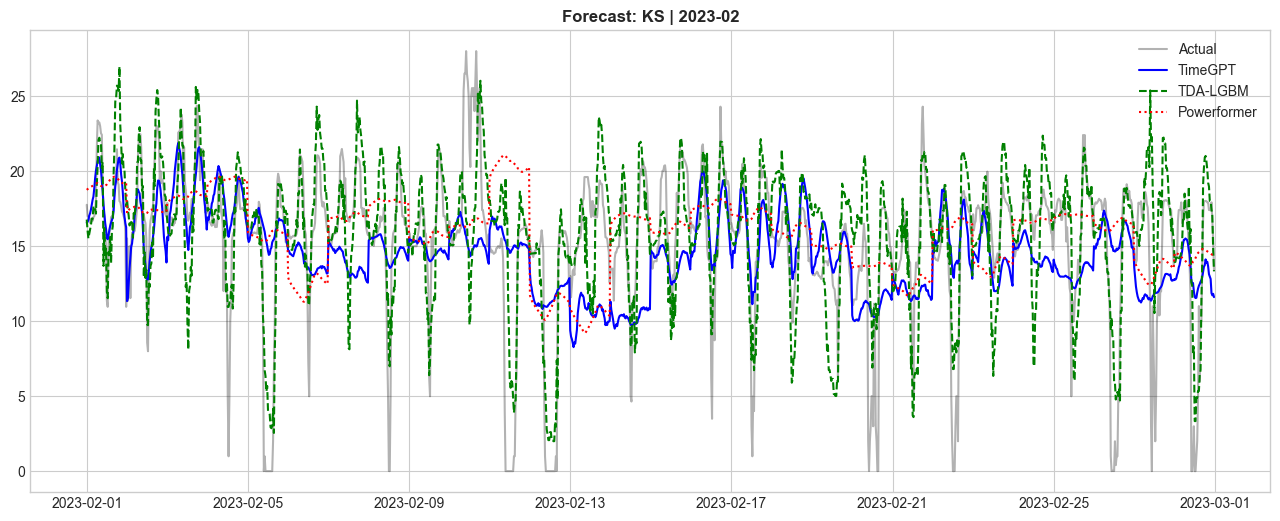

ERROR:__main__:TimeGPT API Failed on 2023-03-29: status_code: 500, body: Could not parse JSON: b'Internal Server Error'


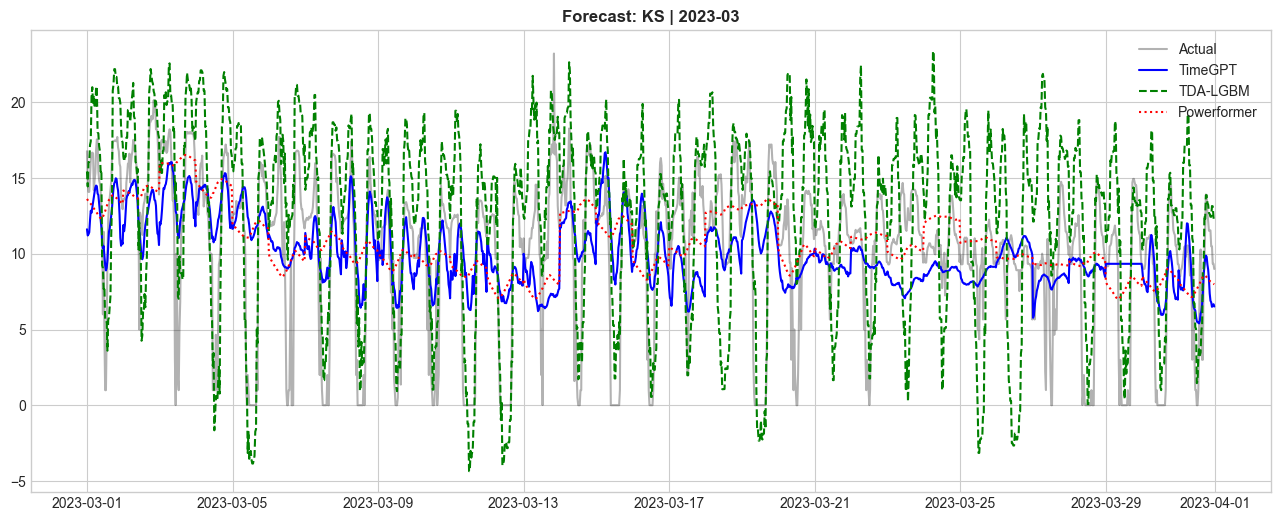

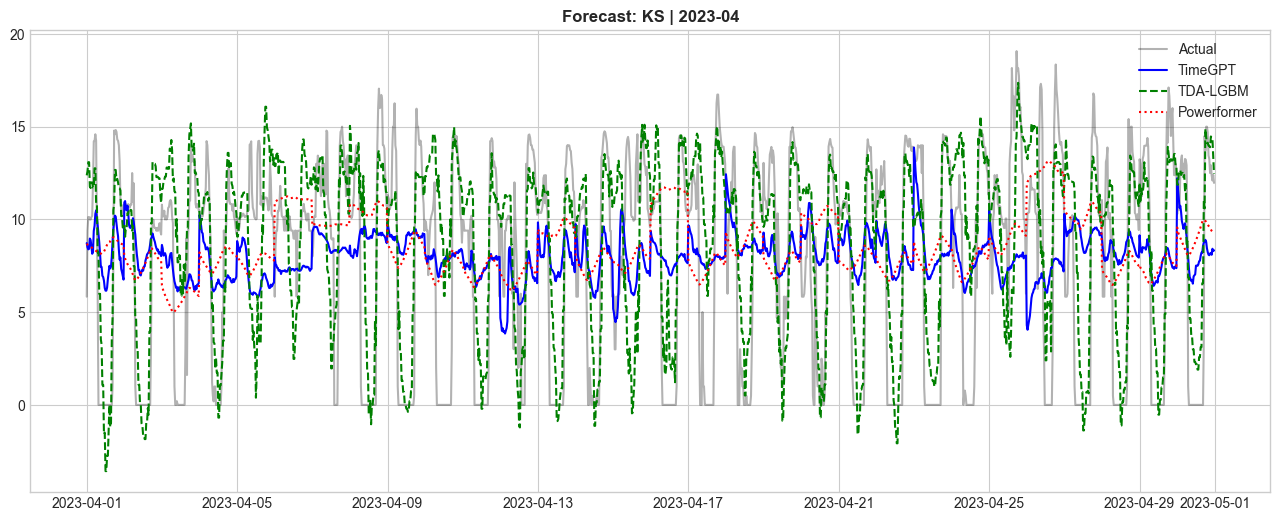

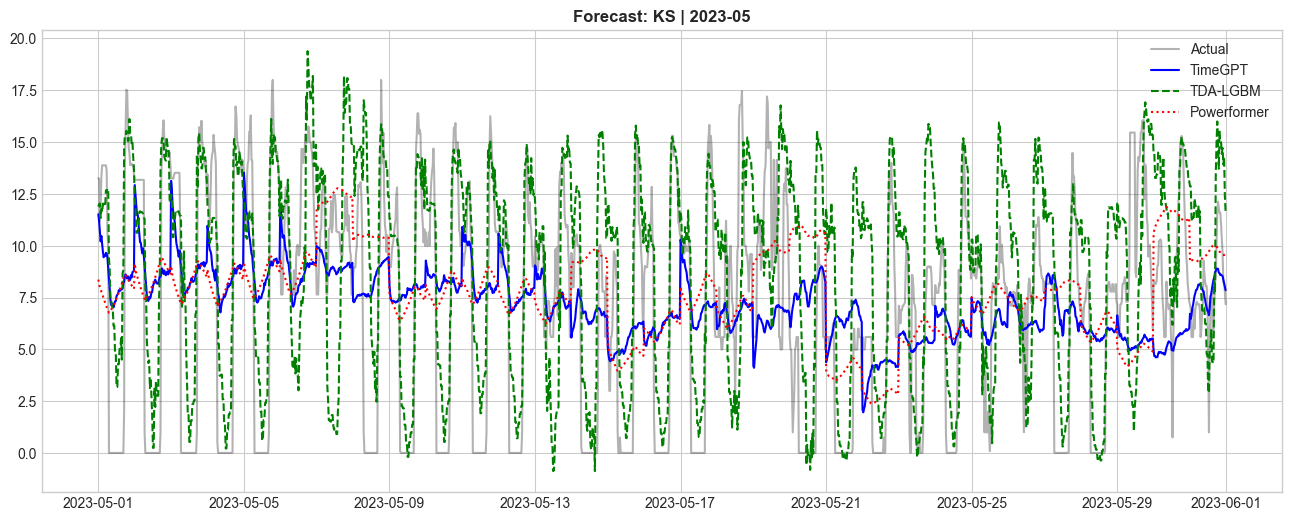

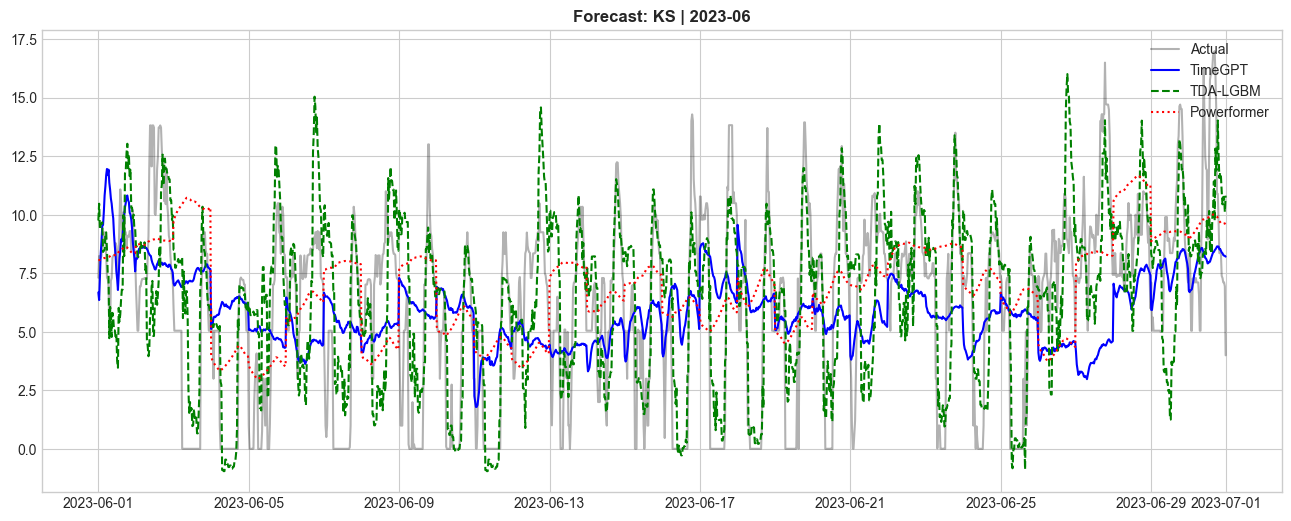

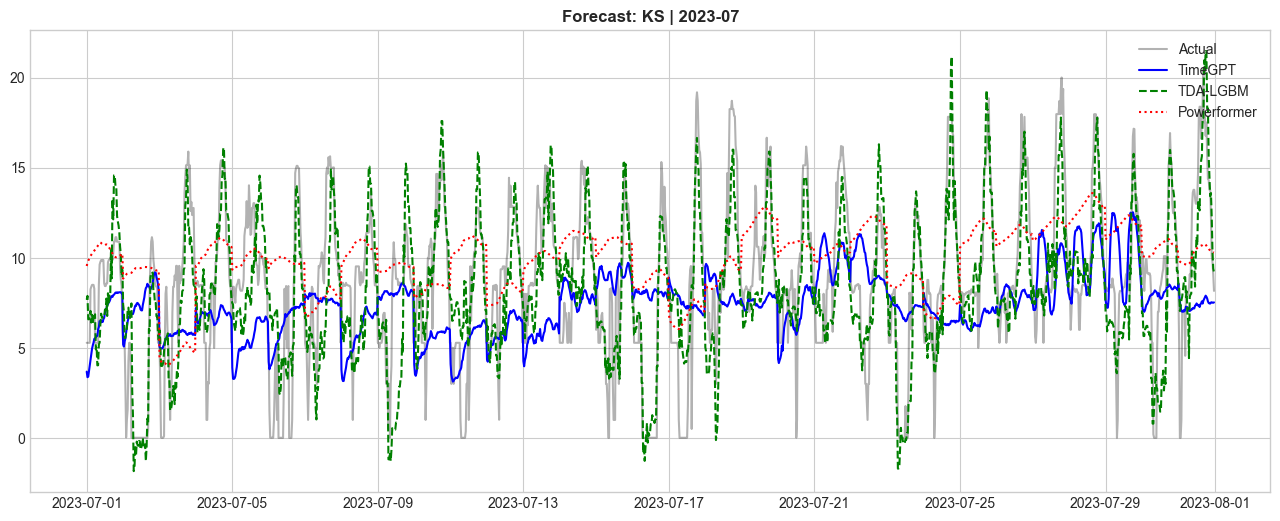

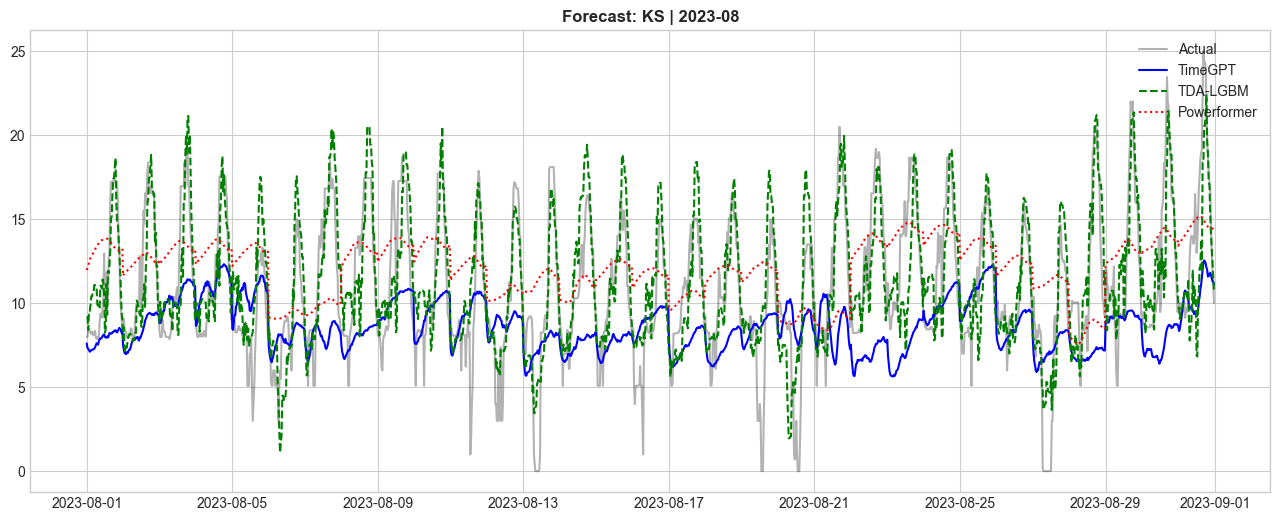

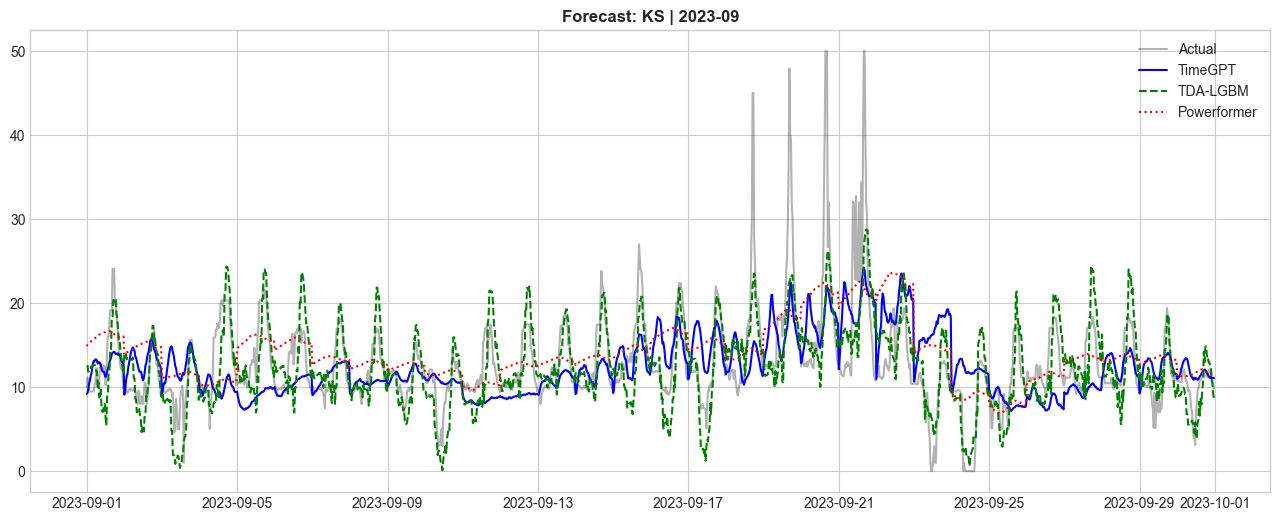

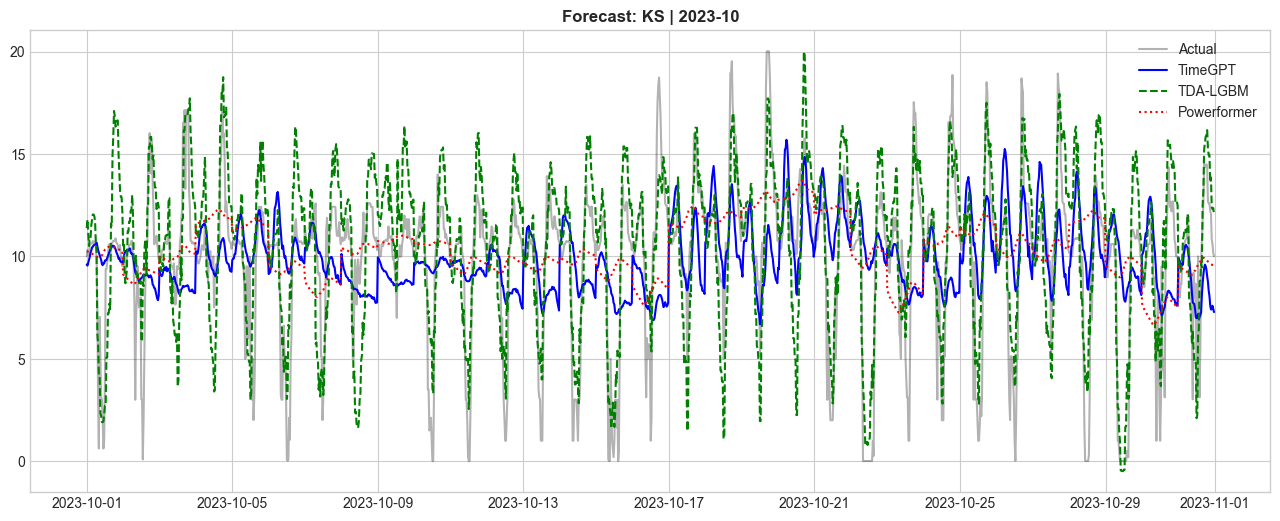

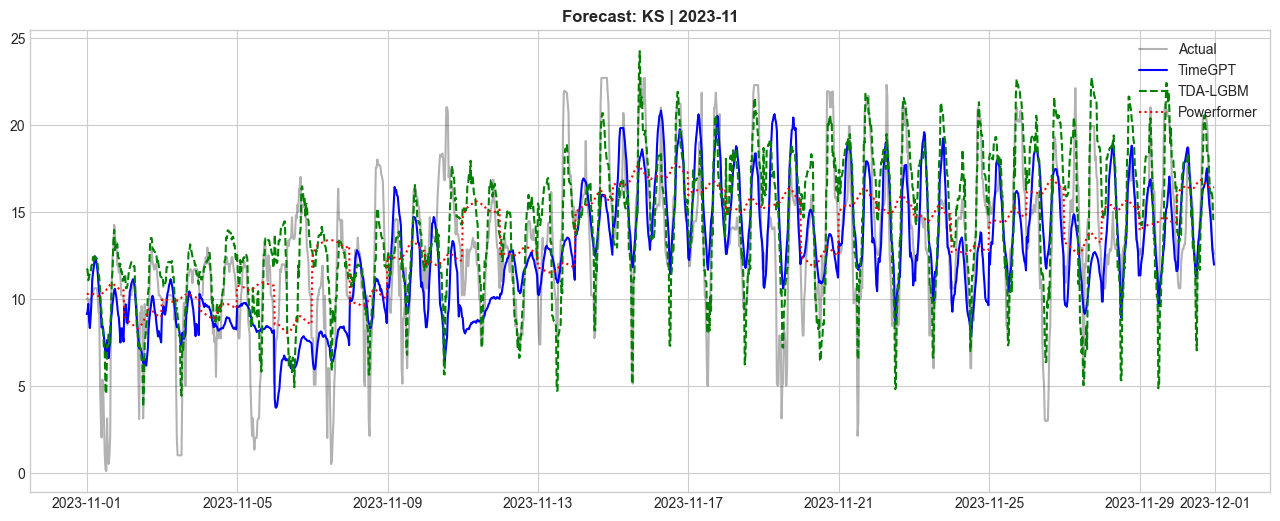

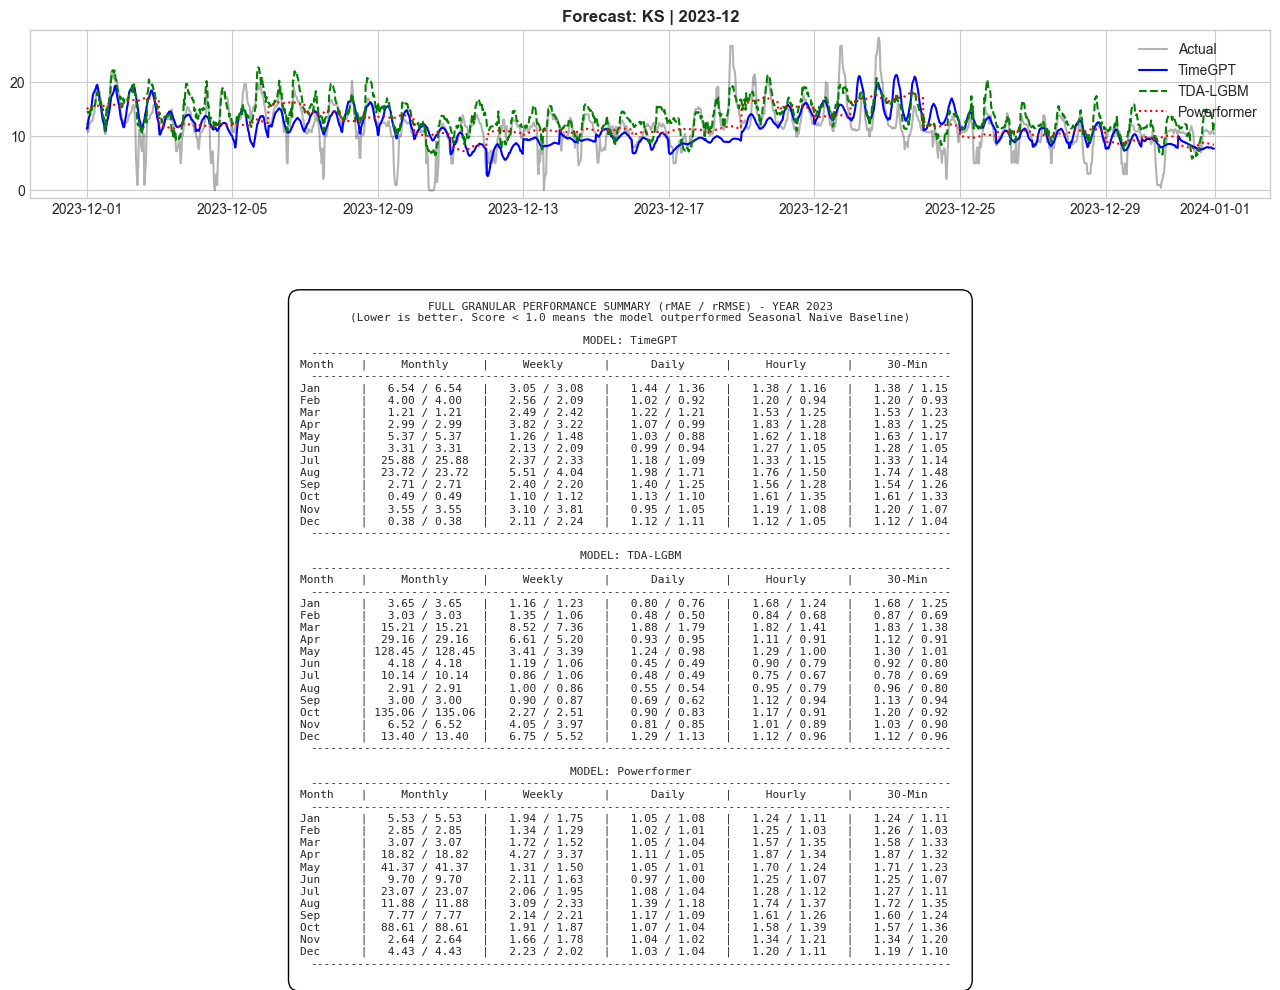

INFO:__main__:Calculating TDA Features for TK...


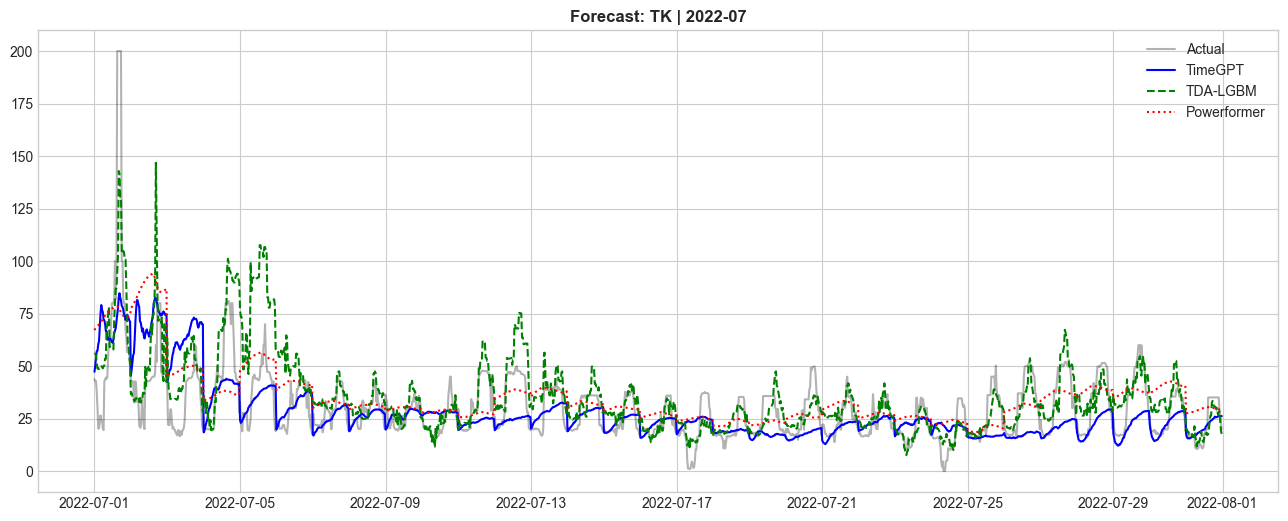

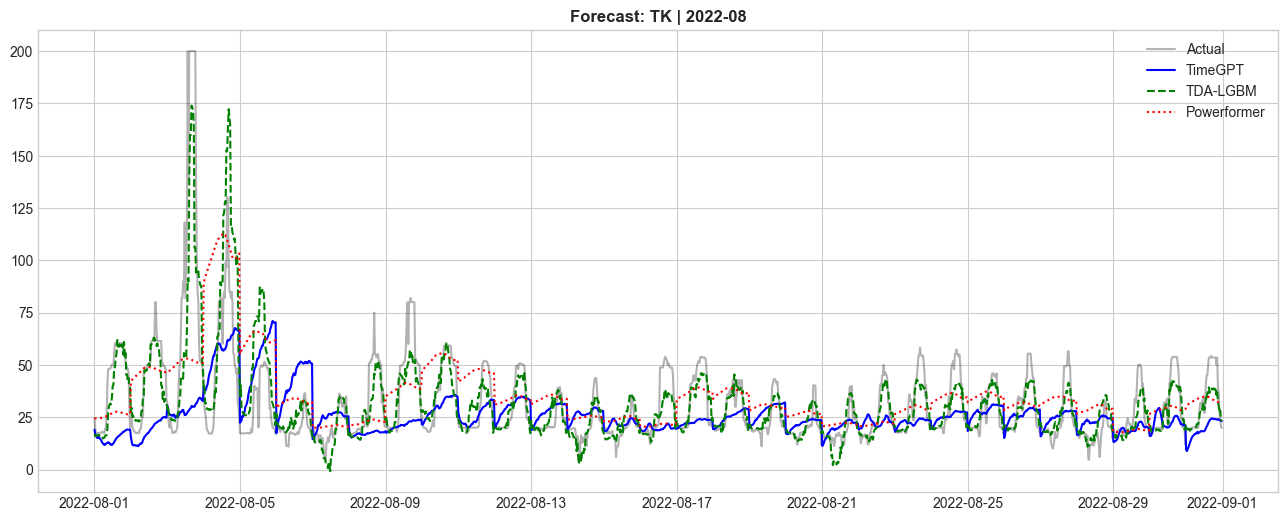

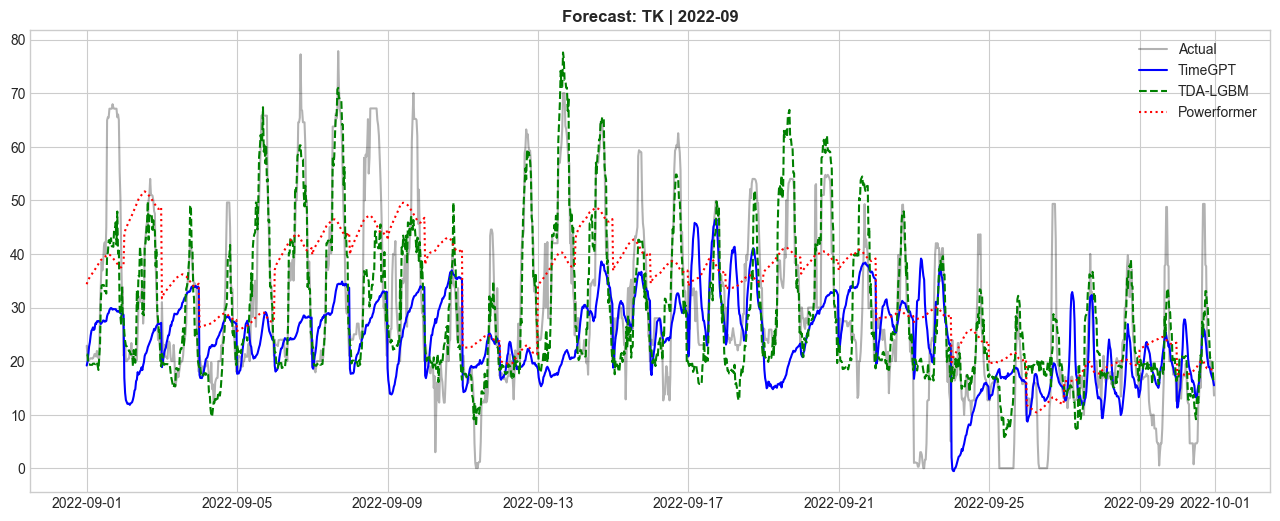

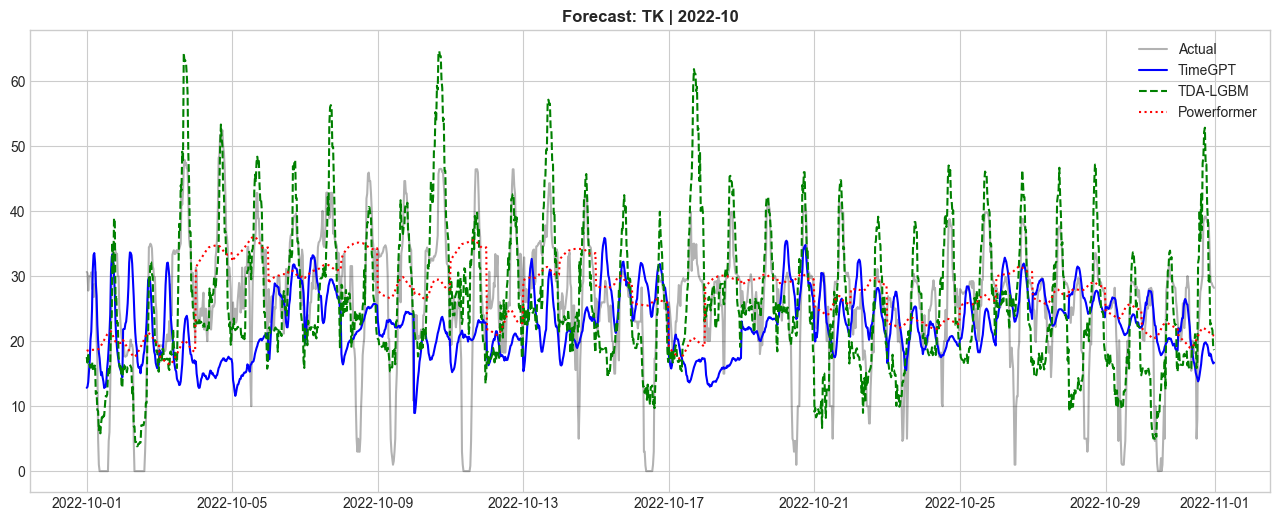

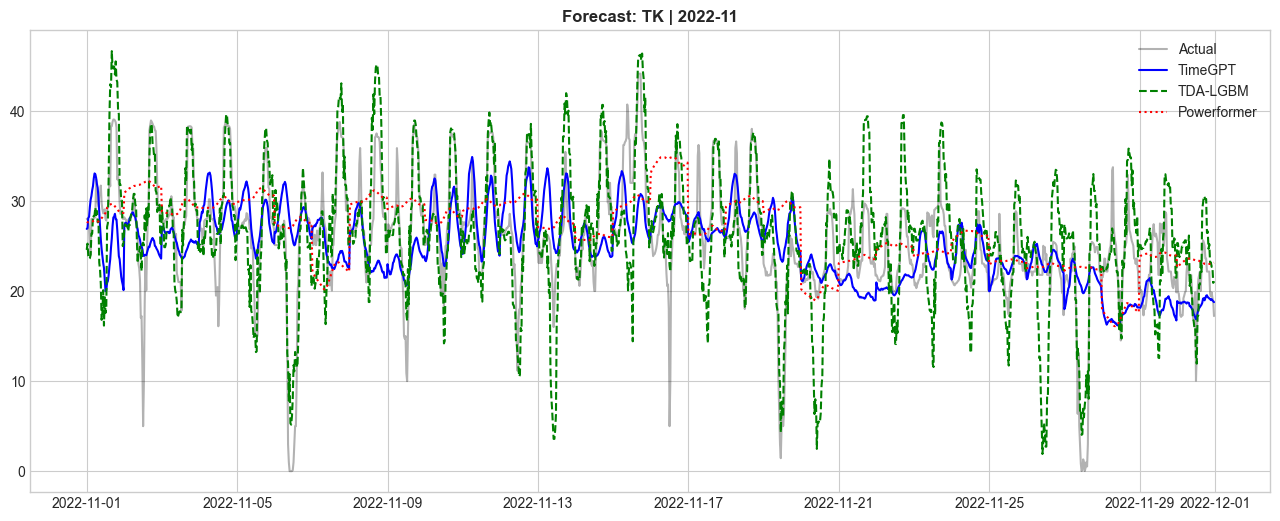

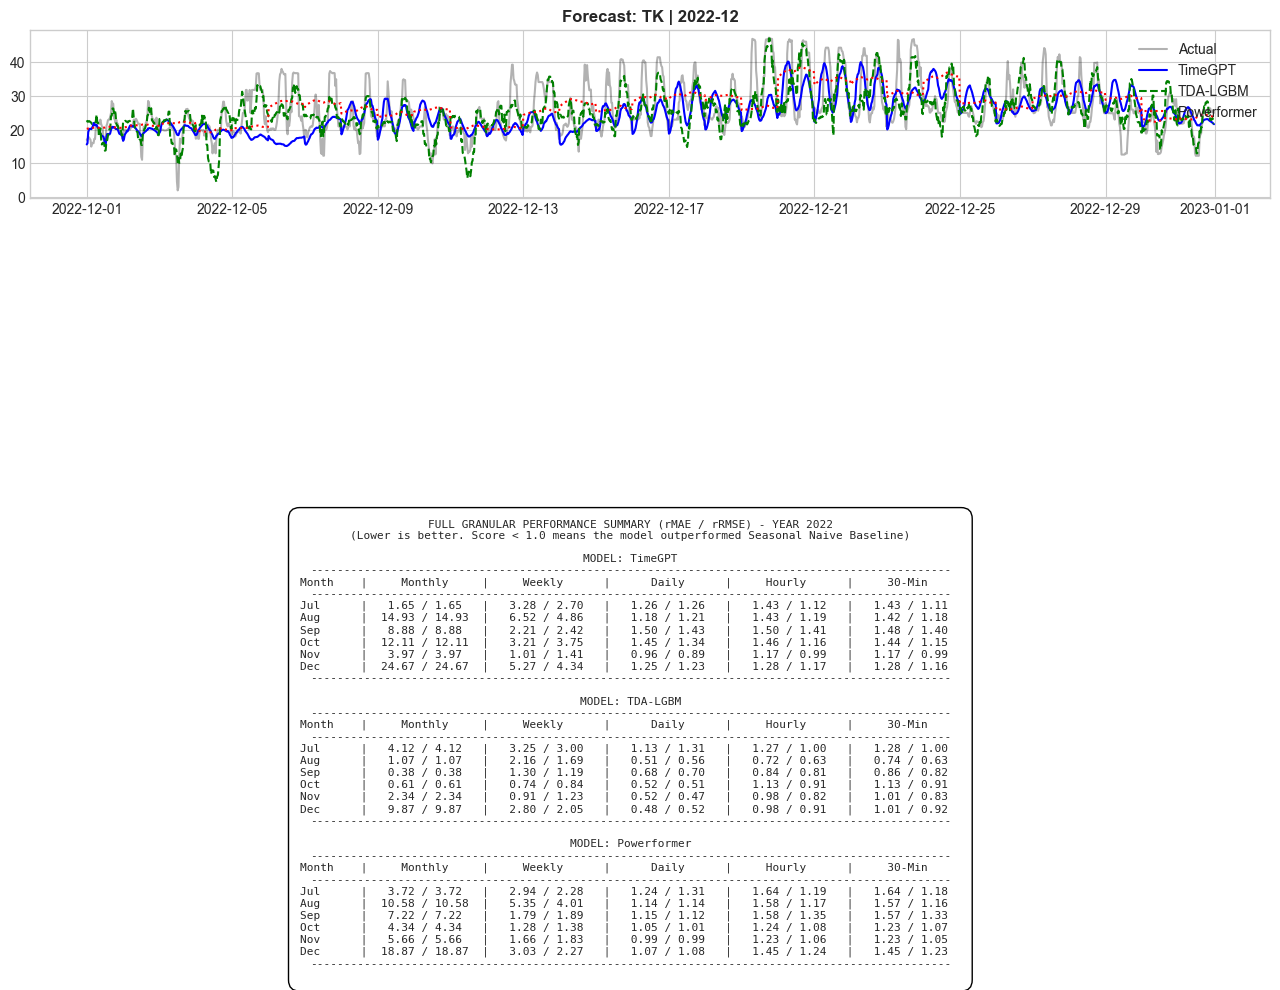

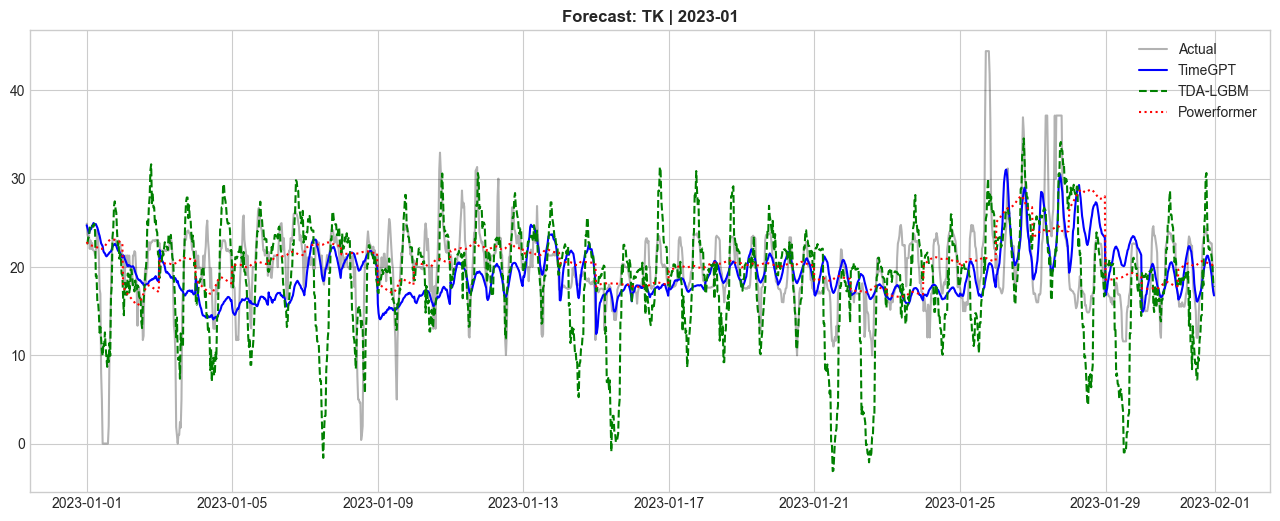

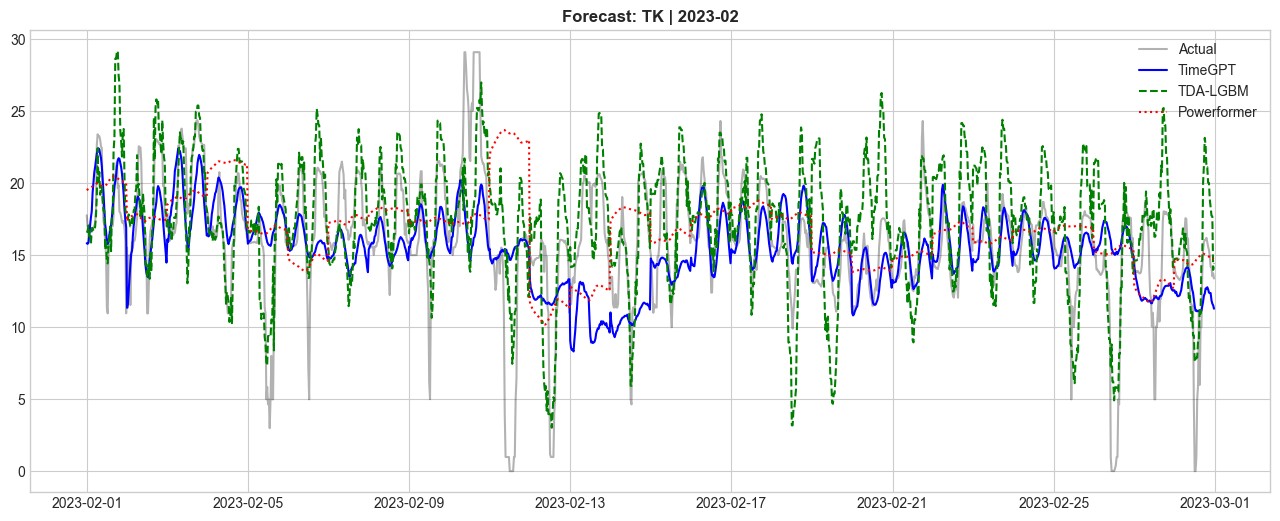

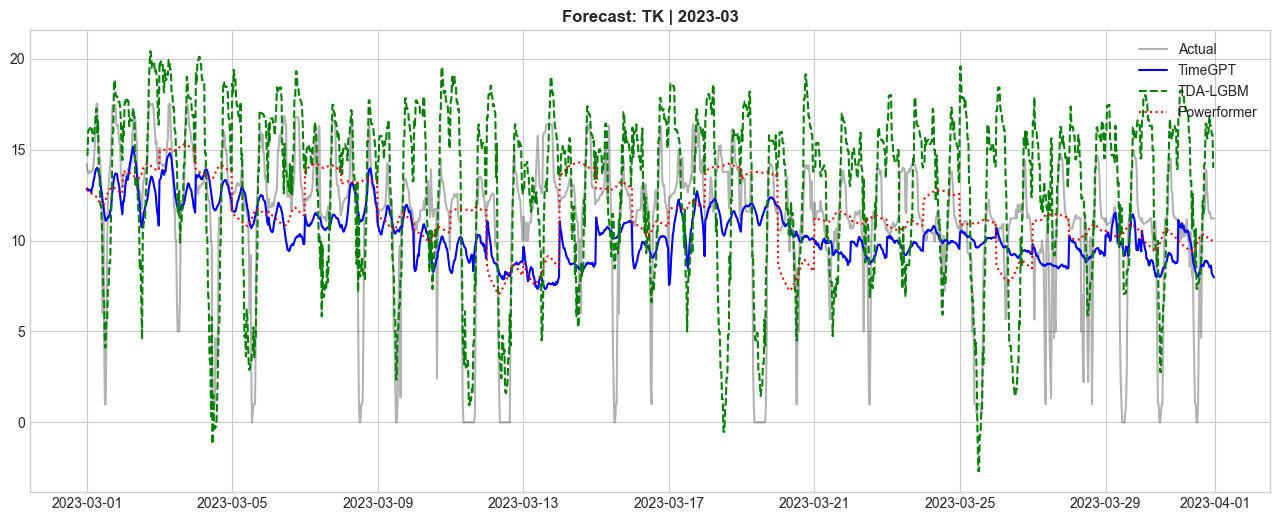

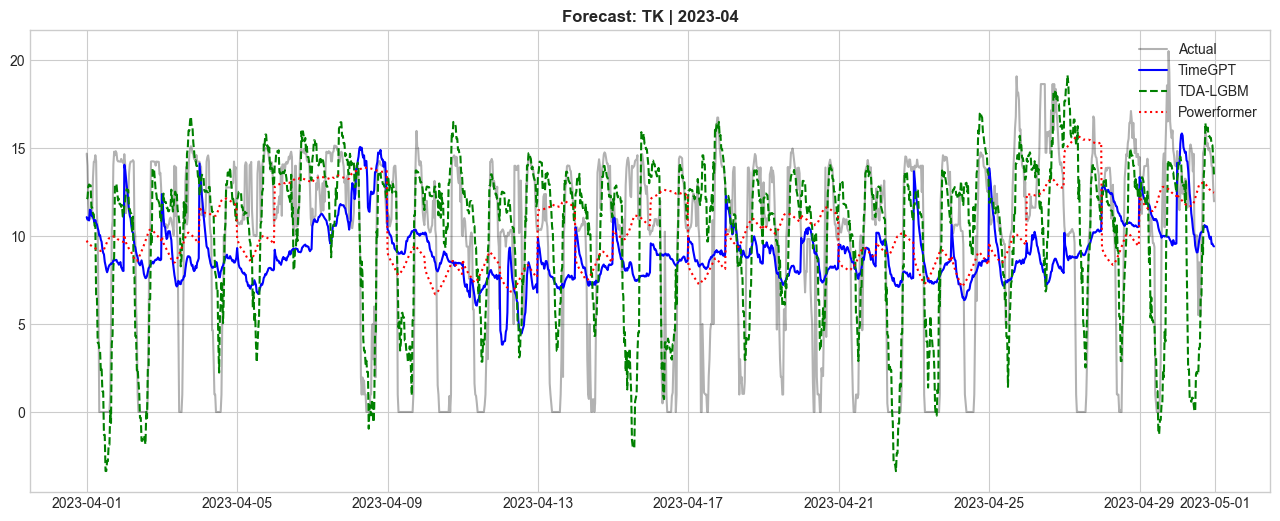

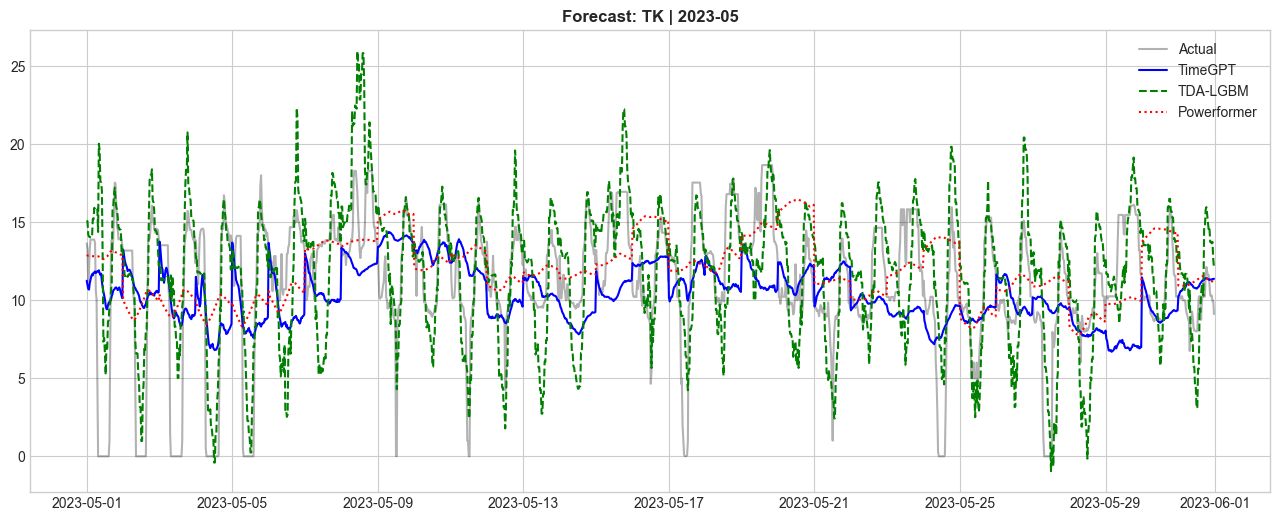

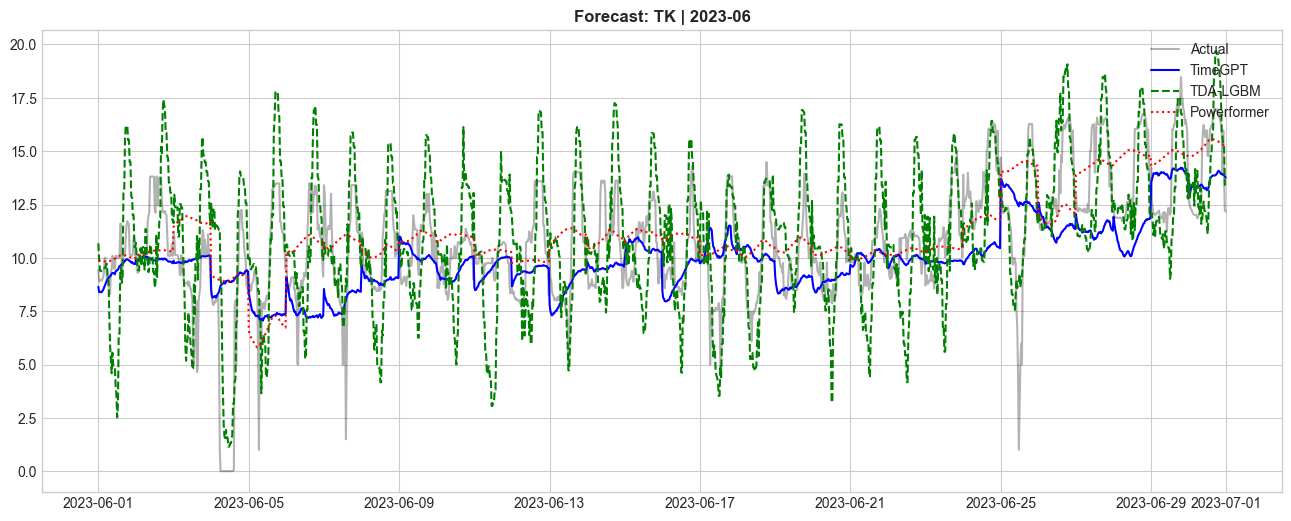

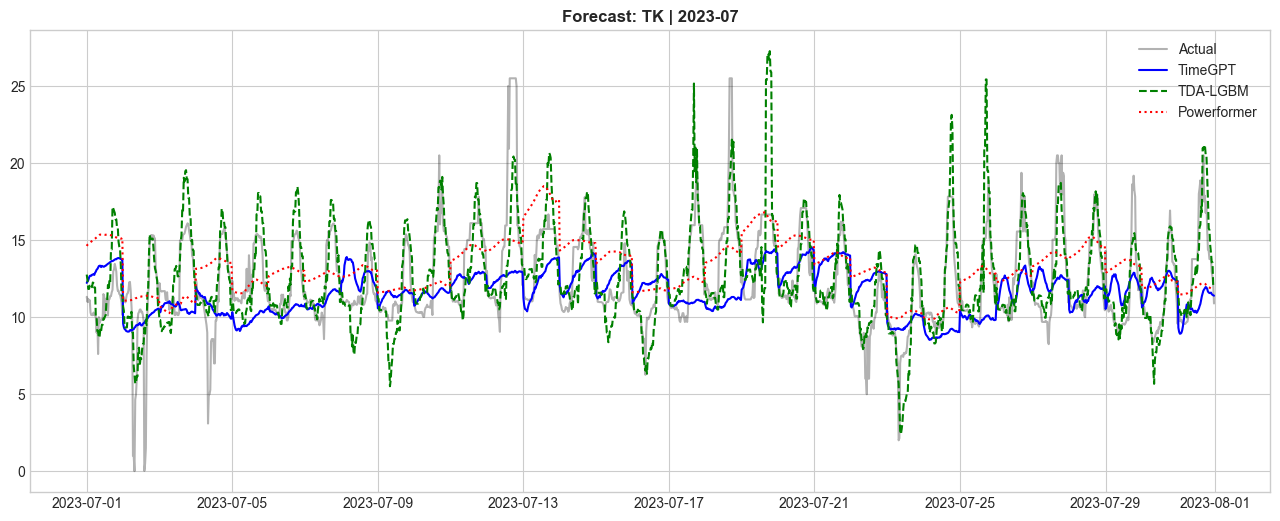

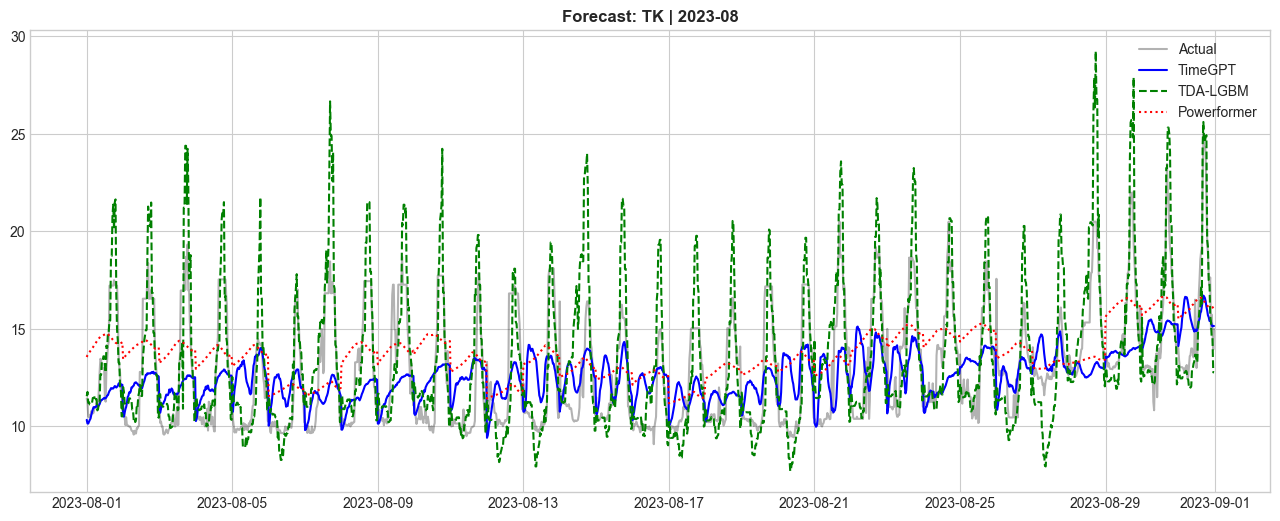

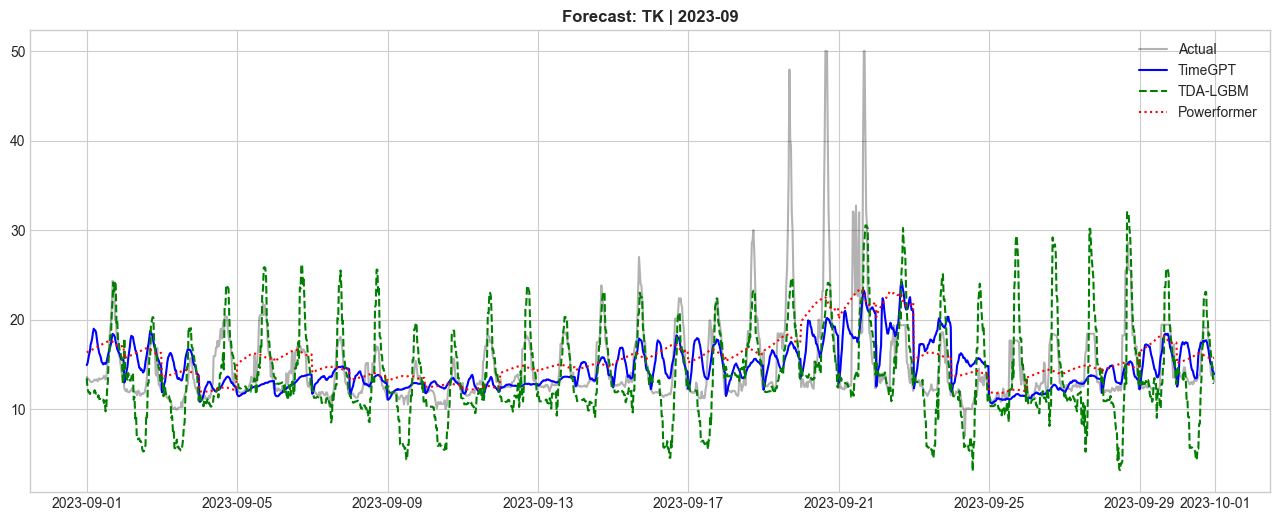

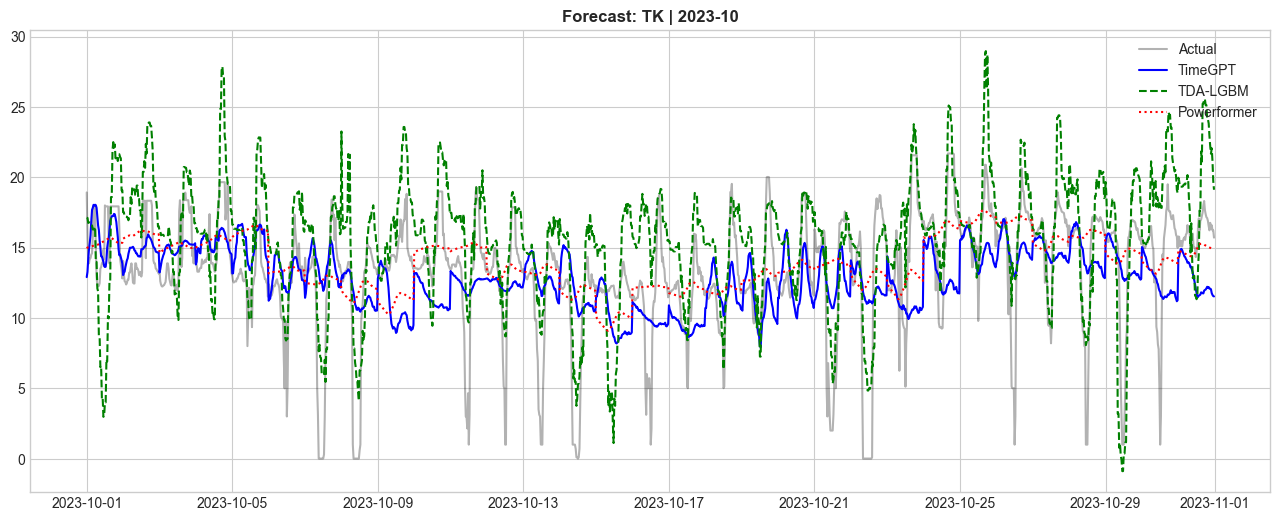

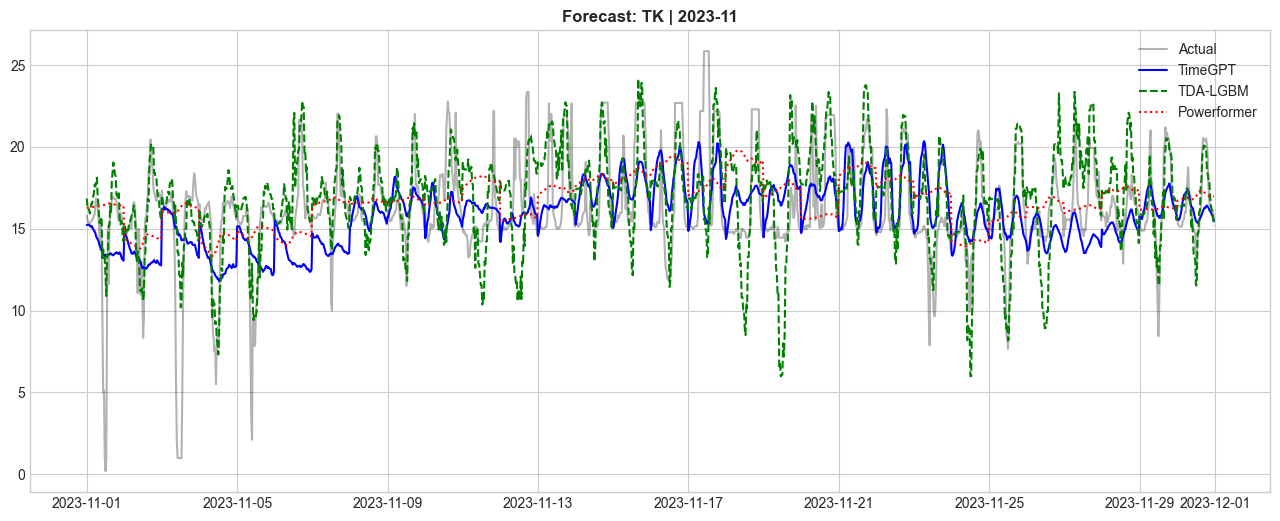

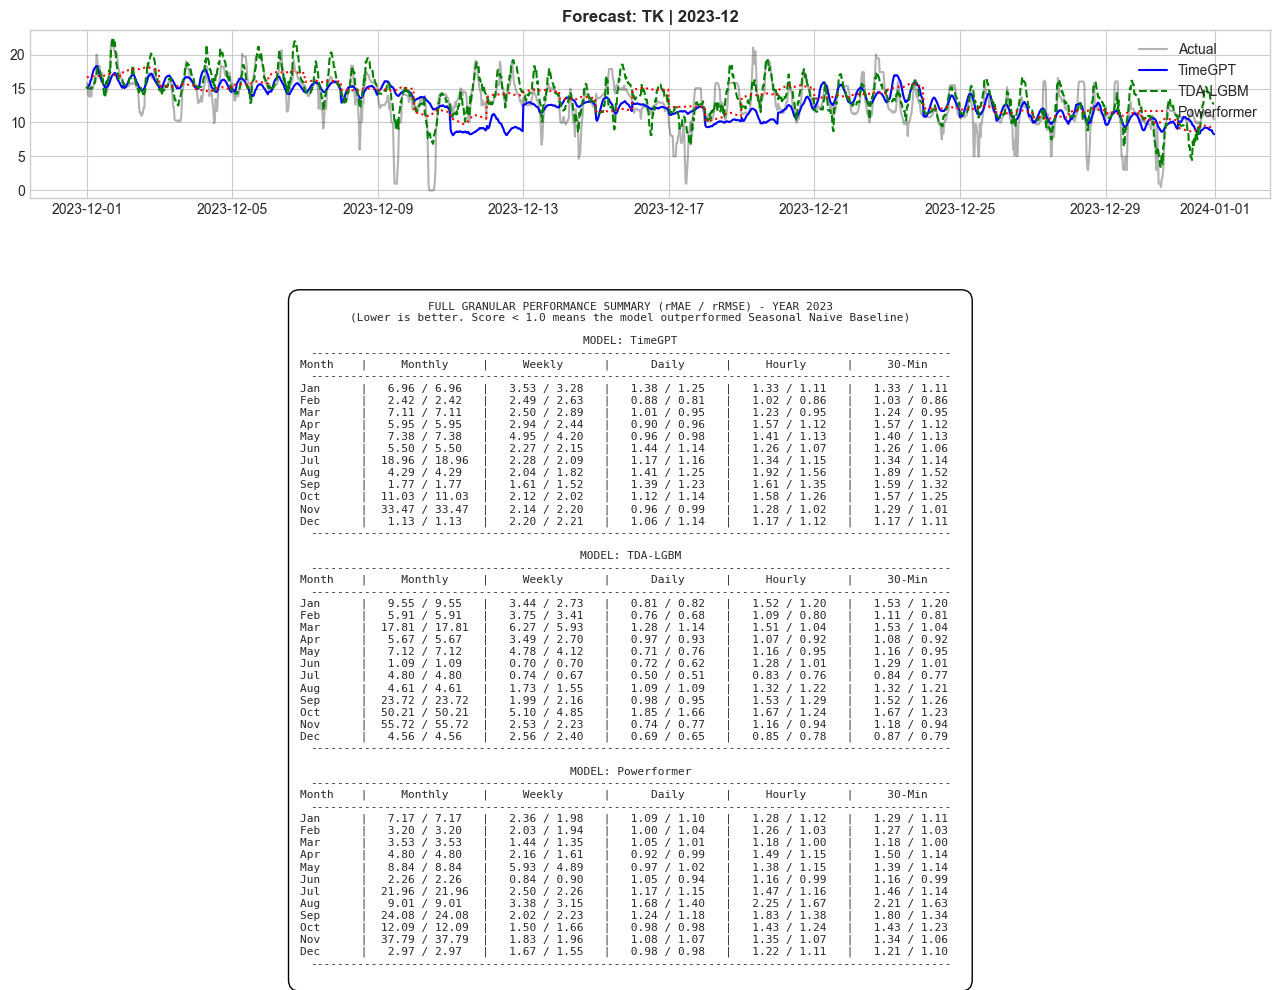

In [2]:
import os
import time
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb 
from nixtla import NixtlaClient
from dotenv import load_dotenv
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1) การตั้งค่าระบบ ---
BASE_DIR = r"D:\Time-GPT"
ENV_PATH = os.path.join(BASE_DIR, "project", ".env")
SAVE_DIR = os.path.join(BASE_DIR, "research_results_SNaive")

load_dotenv(ENV_PATH, override=True)
API_KEY = os.getenv("NIXTLA_API_KEY")
nixtla_client = NixtlaClient(api_key=API_KEY)

TIME_COL, VALUE_COL, FREQ = "ds", "y", "30min"
if not os.path.exists(SAVE_DIR): os.makedirs(SAVE_DIR)

plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)
logging.getLogger("nixtla").setLevel(logging.ERROR)

try:
    from gtda.time_series import SlidingWindow
    from gtda.homology import VietorisRipsPersistence
    from gtda.diagrams import PersistenceEntropy
    HAS_TDA = True
except ImportError:
    HAS_TDA = False

CITY_CONFIG = {
    "KS": {"path": os.path.join(BASE_DIR, "dataset", "KS_ready.csv")},
    "TK": {"path": os.path.join(BASE_DIR, "dataset", "TK_ready.csv")}
}

# --- 2) ฟังก์ชันคำนวณสถิติ ---

def powerformer_sliding_window(history, h_len, alpha=0.5):
    if len(history) == 0: return np.zeros(h_len)
    curr_hist = np.array(history)
    predictions = np.zeros(h_len)
    for i in range(h_len):
        dt = np.arange(1, len(curr_hist) + 1)
        weights = np.exp(-alpha * np.log(dt))
        weights /= weights.sum()
        pred_val = np.dot(curr_hist[::-1], weights)
        predictions[i] = pred_val
        curr_hist = np.append(curr_hist[1:], pred_val)
    return predictions

def get_tda_features(data, window=48):
    if not HAS_TDA or len(data) < window: return np.zeros((len(data), 2))
    try:
        sw = SlidingWindow(size=window, stride=1)
        X_sw = sw.fit_transform(data.reshape(-1, 1))
        vr = VietorisRipsPersistence(homology_dimensions=[0, 1]) 
        entropy = PersistenceEntropy().fit_transform(vr.fit_transform(X_sw))
        return np.pad(entropy, ((window-1, 0), (0, 0)), mode='edge')
    except Exception as e: 
        logger.error(f"TDA Error: {e}")
        return np.zeros((len(data), 2))

def get_relative_metrics(df_res, model_col):
    """
    คำนวณ rMAE และ rRMSE ตามวิธีในเปเปอร์ TimeGPT
    โดยการใช้ Error ของโมเดล หารด้วย Error ของ Seasonal Naive Baseline
    """
    df_res[TIME_COL] = pd.to_datetime(df_res[TIME_COL])
    
    def calc_err(actual, pred):
        mae = mean_absolute_error(actual, pred)
        rmse = np.sqrt(mean_squared_error(actual, pred))
        return mae, rmse
        
    def calc_relative(df_agg):
        model_mae, model_rmse = calc_err(df_agg['actual'], df_agg[model_col])
        snaive_mae, snaive_rmse = calc_err(df_agg['actual'], df_agg['snaive'])
        
        # หารด้วย Seasonal Naive (ถ้า snaive_mae เป็น 0 ให้คืนค่า 0 กัน Error)
        rmae = model_mae / snaive_mae if snaive_mae > 0 else 0
        rrmse = model_rmse / snaive_rmse if snaive_rmse > 0 else 0
        return rmae, rrmse

    # 5. 30-Min (Raw Data)
    m30_rmae, m30_rrmse = calc_relative(df_res)
    
    # 4. Hourly 
    hourly_df = df_res.groupby(df_res[TIME_COL].dt.floor('h'))[['actual', model_col, 'snaive']].sum()
    h_rmae, h_rrmse = calc_relative(hourly_df)
    
    # 3. Daily
    daily_df = df_res.groupby(df_res[TIME_COL].dt.floor('D'))[['actual', model_col, 'snaive']].sum()
    d_rmae, d_rrmse = calc_relative(daily_df)
    
    # 2. Weekly
    weekly_df = df_res.groupby([df_res[TIME_COL].dt.isocalendar().year, df_res[TIME_COL].dt.isocalendar().week])[['actual', model_col, 'snaive']].sum()
    w_rmae, w_rrmse = calc_relative(weekly_df)
    
    # 1. Monthly
    monthly_df = df_res.groupby(df_res[TIME_COL].dt.to_period('M'))[['actual', model_col, 'snaive']].sum()
    m_rmae, m_rrmse = calc_relative(monthly_df)
    
    return {
        'rMAE': [m_rmae, w_rmae, d_rmae, h_rmae, m30_rmae],
        'rRMSE': [m_rrmse, w_rrmse, d_rrmse, h_rrmse, m30_rrmse]
    }

# --- 3) วงจรการวิจัย ---

def run_research_v24(city_id):
    cfg = CITY_CONFIG[city_id]
    df = pd.read_csv(cfg['path'])
    df[TIME_COL] = pd.to_datetime(df["DATETIME"])
    df[VALUE_COL] = pd.to_numeric(df["y"], errors="coerce")
    df = df.sort_values(TIME_COL).ffill().bfill()
    
    df["hour"] = df[TIME_COL].dt.hour
    df["dayofweek"] = df[TIME_COL].dt.dayofweek
    df["month"] = df[TIME_COL].dt.month
    
    if "tda_h0" not in df.columns:
        logger.info(f"Calculating TDA Features for {city_id}...")
        tda_feats = get_tda_features(df[VALUE_COL].values)
        df["tda_h0"], df["tda_h1"] = tda_feats[:, 0], tda_feats[:, 1]
    
    feature_cols = ["hour", "dayofweek", "month", "lag_336", "roll_mean_48", "tda_h0", "tda_h1"]

    for year in [2022, 2023]:
        annual_stats = [] 

        for month in range(1, 13):
            start_m = pd.Timestamp(year, month, 1)
            if year == 2022 and month < 7: continue 
            if start_m > df[TIME_COL].max(): continue
            
            checkpoint_file = os.path.join(SAVE_DIR, f"{city_id}_{year}_{month:02d}.csv")
            
            if os.path.exists(checkpoint_file):
                full_res = pd.read_csv(checkpoint_file)
                full_res[TIME_COL] = pd.to_datetime(full_res[TIME_COL])
            else:
                train_data = df[df[TIME_COL] < start_m].dropna()
                lgbm_model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.03, random_state=42, verbosity=-1)
                lgbm_model.fit(train_data[feature_cols], train_data[VALUE_COL])
                
                results_list = []
                for day in pd.date_range(start_m, start_m + pd.offsets.MonthEnd(1), freq='D'):
                    day_mask = (df[TIME_COL] >= day) & (df[TIME_COL] < day + pd.Timedelta(days=1))
                    actual_day = df[day_mask]
                    
                    if actual_day.empty: continue
                    hist = df[df[TIME_COL] < day].tail(1500)[[TIME_COL, VALUE_COL]]
                    
                    # --- สร้าง Seasonal Naive ---
                    # ดึงข้อมูลของ 1 วันก่อนหน้า (ความยาวเท่ากับ actual_day) เพื่อใช้เป็นค่า Baseline พื้นฐาน
                    if len(hist) >= len(actual_day):
                        snaive_day = hist[VALUE_COL].tail(len(actual_day)).values
                    else:
                        snaive_day = np.zeros(len(actual_day))
                    
                    try:
                        gpt_res = nixtla_client.forecast(hist, h=len(actual_day), freq=FREQ)
                        gpt_day = gpt_res['TimeGPT'].values
                    except Exception as e:
                        logger.error(f"TimeGPT API Failed on {day.date()}: {e}")
                        last_val = hist[VALUE_COL].iloc[-1] if not hist.empty else 0
                        gpt_day = np.full(len(actual_day), last_val)
                    
                    lgbm_day = lgbm_model.predict(actual_day[feature_cols])
                    pwr_day = powerformer_sliding_window(df[df[TIME_COL] < day][VALUE_COL].tail(48).values, len(actual_day))
                    
                    results_list.append(pd.DataFrame({
                        TIME_COL: actual_day[TIME_COL], 
                        'actual': actual_day[VALUE_COL].values, 
                        'snaive': snaive_day, # บันทึกผล Seasonal Naive ไว้หารตอนจบ
                        'gpt': gpt_day, 
                        'lgbm': lgbm_day, 
                        'pwr': pwr_day
                    }))
                    
                full_res = pd.concat(results_list)
                full_res.to_csv(checkpoint_file, index=False)

            m_stats = {m: get_relative_metrics(full_res, c) for m, c in zip(['TimeGPT', 'TDA-LGBM', 'Powerformer'], ['gpt', 'lgbm', 'pwr'])}
            annual_stats.append({'month_name': start_m.strftime('%b'), 'stats': m_stats})

            # --- PLOTTING ---
            fig, ax = plt.subplots(figsize=(16, 6))
            ax.plot(full_res[TIME_COL], full_res['actual'], color='black', alpha=0.3, label='Actual')
            ax.plot(full_res[TIME_COL], full_res['gpt'], color='blue', label='TimeGPT')
            ax.plot(full_res[TIME_COL], full_res['lgbm'], color='green', linestyle='--', label='TDA-LGBM')
            ax.plot(full_res[TIME_COL], full_res['pwr'], color='red', linestyle=':', label='Powerformer')
            ax.set_title(f"Forecast: {city_id} | {year}-{month:02d}", fontsize=12, fontweight='bold')
            ax.legend(loc='upper right')

            is_last = (month == 12 or start_m + pd.offsets.MonthEnd(1) > df[TIME_COL].max())
            if is_last:
                final_table = f"FULL GRANULAR PERFORMANCE SUMMARY (rMAE / rRMSE) - YEAR {year}\n"
                final_table += f"(Lower is better. Score < 1.0 means the model outperformed Seasonal Naive Baseline)\n"
                header = f"{'Month':<8} | {'Monthly':^15} | {'Weekly':^15} | {'Daily':^15} | {'Hourly':^15} | {'30-Min':^15}\n"
                divider = "-" * 95 + "\n"
                
                table_str = ""
                for model in ['TimeGPT', 'TDA-LGBM', 'Powerformer']:
                    model_box = f"\nMODEL: {model}\n" + divider + header + divider
                    for entry in annual_stats:
                        rmae = entry['stats'][model]['rMAE']
                        rrmse = entry['stats'][model]['rRMSE']
                        
                        m_str = f"{rmae[0]:.2f} / {rrmse[0]:.2f}"
                        w_str = f"{rmae[1]:.2f} / {rrmse[1]:.2f}"
                        d_str = f"{rmae[2]:.2f} / {rrmse[2]:.2f}"
                        h_str = f"{rmae[3]:.2f} / {rrmse[3]:.2f}"
                        m30_str = f"{rmae[4]:.2f} / {rrmse[4]:.2f}"
                        
                        model_box += f"{entry['month_name']:<8} | {m_str:^15} | {w_str:^15} | {d_str:^15} | {h_str:^15} | {m30_str:^15}\n"
                    table_str += model_box + divider
                
                plt.figtext(0.5, -0.7, final_table + table_str, ha="center", family='monospace', fontsize=8, bbox={"facecolor":"white", "boxstyle":"round,pad=1"})
                plt.subplots_adjust(bottom=0.6)

            plt.show()
            plt.close()

if __name__ == "__main__":
    run_research_v24("KS")
    run_research_v24("TK")